In [26]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from collections import Counter
import re

In [9]:
data = pd.read_csv("/content/IMDB Dataset.csv")
data.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [10]:
le = LabelEncoder()
data['sentiment'] = le.fit_transform(data['sentiment'])
data.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,1
1,A wonderful little production. <br /><br />The...,1
2,I thought this was a wonderful way to spend ti...,1
3,Basically there's a family where a little boy ...,0
4,"Petter Mattei's ""Love in the Time of Money"" is...",1


In [11]:
data.describe()

,sentiment
count,50000.000000
mean,0.500000
std,0.500005
min,0.000000
25%,0.000000
50%,0.500000
75%,1.000000
max,1.000000


In [12]:
from sklearn.model_selection import train_test_split

features = data['review']
targets = data['sentiment']
X_train, X_temp, y_train, y_temp = train_test_split(
    features, targets, test_size=0.20, random_state=42, stratify=targets
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp
)

print(f"Train size: {len(X_train)}")
print(f"Val size: {len(X_val)}")
print(f"Test size: {len(X_test)}")

Train size: 40000
Val size: 7500
Test size: 2500


In [13]:
print("\n--- Sample Review ---")
print(X_train.iloc[0])
print(y_train.iloc[0])


--- Sample Review ---
I caught this little gem totally by accident back in 1980 or '81. I was at a revival theatre to see two old silly sci-fi movies. The theatre was packed full and (with no warning) they showed a bunch of sci-fi short spoofs (to get us in the mood). Most were somewhat amusing but THIS came on and, within seconds, the audience was in hysterics! The biggest laugh came when they showed "Princess Laia" having huge cinnamon buns instead of hair on her head. She looks at the camera, gives a grim smile and nods. That made it even funnier! You gotta see "Chewabacca" played by what looks like a Muppet! It was extremely silly and stupid...but I couldn't stop laughing. Most of the dialogue was drowned out because of all the laughter. Also if you know "Star Wars" pretty well it's even funnier--they deliberately poke fun at some of the dialogue. This REALLY works with an audience! A definite 10!
1


In [14]:
def clean_text(text):
  return re.sub(r"[^a-zA-Z0-9\s]", "", text.lower()).split()

In [15]:
def build_vocab(reviews, max_vocab=10000):
  all_words = []
  for text in reviews:
    all_words.extend(clean_text(text))
  counts = Counter(all_words)
  w2id = {word : i + 2 for i, (word, count) in enumerate(counts.most_common(max_vocab - 2))}
  w2id['<pad>'] = 0
  w2id['<OOV>'] = 1
  id2w = {i : w for w, i in w2id.items()}
  return w2id, id2w

In [16]:
def reviews_to_tensor(reviews, labels, w2id, max_length=200):
    encoded_reviews = []
    for text in reviews:
        tokens = clean_text(text)

        encoded = [w2id.get(w, 1) for w in tokens]

        # Pad or Truncate
        if len(encoded) < max_length:
            # 0 is the index for <PAD>
            encoded += [0] * (max_length - len(encoded))
        else:
            encoded = encoded[:max_length]
        encoded_reviews.append(encoded)

    return torch.tensor(encoded_reviews), torch.tensor(labels.values).float()

In [17]:
w2id, id2w = build_vocab(X_train)

X_train_t, y_train_t = reviews_to_tensor(X_train, y_train, w2id)
X_val_t, y_val_t = reviews_to_tensor(X_val, y_val, w2id)
X_test_t, y_test_t = reviews_to_tensor(X_test, y_test, w2id)

In [18]:
# Check the first review in the training set
print([id2w[idx.item()] for idx in X_train_t[0]])

['i', 'caught', 'this', 'little', 'gem', 'totally', 'by', 'accident', 'back', 'in', '1980', 'or', '<OOV>', 'i', 'was', 'at', 'a', 'revival', 'theatre', 'to', 'see', 'two', 'old', 'silly', 'scifi', 'movies', 'the', 'theatre', 'was', 'packed', 'full', 'and', 'with', 'no', 'warning', 'they', 'showed', 'a', 'bunch', 'of', 'scifi', 'short', 'spoofs', 'to', 'get', 'us', 'in', 'the', 'mood', 'most', 'were', 'somewhat', 'amusing', 'but', 'this', 'came', 'on', 'and', 'within', 'seconds', 'the', 'audience', 'was', 'in', '<OOV>', 'the', 'biggest', 'laugh', 'came', 'when', 'they', 'showed', 'princess', '<OOV>', 'having', 'huge', '<OOV>', '<OOV>', 'instead', 'of', 'hair', 'on', 'her', 'head', 'she', 'looks', 'at', 'the', 'camera', 'gives', 'a', 'grim', 'smile', 'and', '<OOV>', 'that', 'made', 'it', 'even', 'funnier', 'you', 'gotta', 'see', '<OOV>', 'played', 'by', 'what', 'looks', 'like', 'a', 'muppet', 'it', 'was', 'extremely', 'silly', 'and', '<OOV>', 'i', 'couldnt', 'stop', 'laughing', 'most', '

In [19]:
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=32, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val_t, y_val_t), batch_size=32)

In [20]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [29]:
import torch.nn as nn

class SentimentModel(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, model_type='RNN', drop_prob=0.5):
        super(SentimentModel, self).__init__()

        self.embedding = nn.Embedding(vocab_size, embed_dim)

        if model_type == 'RNN':
            self.rnn = nn.RNN(embed_dim, hidden_dim, num_layers=2, batch_first=True, dropout=drop_prob)
        elif model_type == 'LSTM':
            self.rnn = nn.LSTM(embed_dim, hidden_dim, num_layers=2, batch_first=True, dropout=drop_prob)
        elif model_type == 'GRU':
            self.rnn = nn.GRU(embed_dim, hidden_dim, num_layers=2, batch_first=True, dropout=drop_prob)

        self.dropout = nn.Dropout(drop_prob)

        self.fc = nn.Linear(hidden_dim, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        embedded = self.embedding(x)

        if isinstance(self.rnn, nn.LSTM):
            out, (hidden, cell) = self.rnn(embedded)
        else:
            out, hidden = self.rnn(embedded)

        last_hidden = hidden[-1]

        out = self.dropout(last_hidden)

        return self.sigmoid(self.fc(out))

In [32]:
def train_and_validate(model, train_loader, val_loader, optimizer, criterion, epochs, device, model_name):
    history = {
        'train_loss': [], 'train_acc': [],
        'val_loss': [], 'val_acc': []
    }

    best_val_loss = float('inf')
    patience = 3
    patience_counter = 0

    for epoch in range(epochs):
        # --- TRAINING PHASE ---
        model.train()
        train_loss = 0
        train_correct = 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()

            outputs = model(inputs).squeeze()
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            preds = (outputs > 0.5).float()
            train_correct += (preds == labels).sum().item()

        # --- VALIDATION PHASE ---
        model.eval()
        val_loss = 0
        val_correct = 0

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs).squeeze()
                loss = criterion(outputs, labels)

                val_loss += loss.item()
                preds = (outputs > 0.5).float()
                val_correct += (preds == labels).sum().item()

        avg_train_loss = train_loss / len(train_loader)
        avg_train_acc = train_correct / len(train_loader.dataset)
        avg_val_loss = val_loss / len(val_loader)
        avg_val_acc = val_correct / len(val_loader.dataset)

        history['train_loss'].append(avg_train_loss)
        history['train_acc'].append(avg_train_acc)
        history['val_loss'].append(avg_val_loss)
        history['val_acc'].append(avg_val_acc)

        print(f"Epoch [{epoch+1}/{epochs}] "
              f"Train Loss: {avg_train_loss:.4f} Acc: {avg_train_acc:.2%} | "
              f"Val Loss: {avg_val_loss:.4f} Acc: {avg_val_acc:.2%}")

        #  EARLY STOPPING
        if avg_val_loss < best_val_loss:
          best_val_loss = avg_val_loss
          filename = f'best_{model_name}_model.pt' # Dynamic naming!
          torch.save(model.state_dict(), filename)
          patience_counter = 0
          print(f"  --> {filename} saved! (Val Loss: {best_val_loss:.4f})")
        else:
            patience_counter += 1
            print(f"  --> Patience: {patience_counter}/{patience}")

        if patience_counter >= patience:
            print(f"Early stopping triggered at epoch {epoch+1}")
            break

    return history

In [35]:
vocab_size = len(w2id)
embed_dim = 128
hidden_dim = 256
epochs = 10

results = {}

for m_type in ['RNN', 'LSTM', 'GRU']:
    print(f"\n--- Training {m_type} ---")
    model = SentimentModel(vocab_size, 128, 256, model_type=m_type, drop_prob=0.5).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    criterion = torch.nn.BCELoss()

    # Train
    history = train_and_validate(model, train_loader, val_loader, optimizer, criterion, epochs, device, m_type)

    # Store history for visualization
    results[m_type] = history


--- Training RNN ---
Epoch [1/10] Train Loss: 0.7039 Acc: 50.29% | Val Loss: 0.7136 Acc: 50.55%
  --> best_RNN_model.pt saved! (Val Loss: 0.7136)
Epoch [2/10] Train Loss: 0.7012 Acc: 49.69% | Val Loss: 0.6998 Acc: 49.48%
  --> best_RNN_model.pt saved! (Val Loss: 0.6998)
Epoch [3/10] Train Loss: 0.7012 Acc: 50.15% | Val Loss: 0.6997 Acc: 49.60%
  --> best_RNN_model.pt saved! (Val Loss: 0.6997)
Epoch [4/10] Train Loss: 0.7007 Acc: 50.12% | Val Loss: 0.6974 Acc: 49.52%
  --> best_RNN_model.pt saved! (Val Loss: 0.6974)
Epoch [5/10] Train Loss: 0.7009 Acc: 50.08% | Val Loss: 0.6959 Acc: 50.67%
  --> best_RNN_model.pt saved! (Val Loss: 0.6959)
Epoch [6/10] Train Loss: 0.7019 Acc: 49.84% | Val Loss: 0.6974 Acc: 49.45%
  --> Patience: 1/3
Epoch [7/10] Train Loss: 0.7005 Acc: 50.37% | Val Loss: 0.6943 Acc: 50.39%
  --> best_RNN_model.pt saved! (Val Loss: 0.6943)
Epoch [8/10] Train Loss: 0.7008 Acc: 50.06% | Val Loss: 0.6978 Acc: 49.81%
  --> Patience: 1/3
Epoch [9/10] Train Loss: 0.7004 Acc: 5

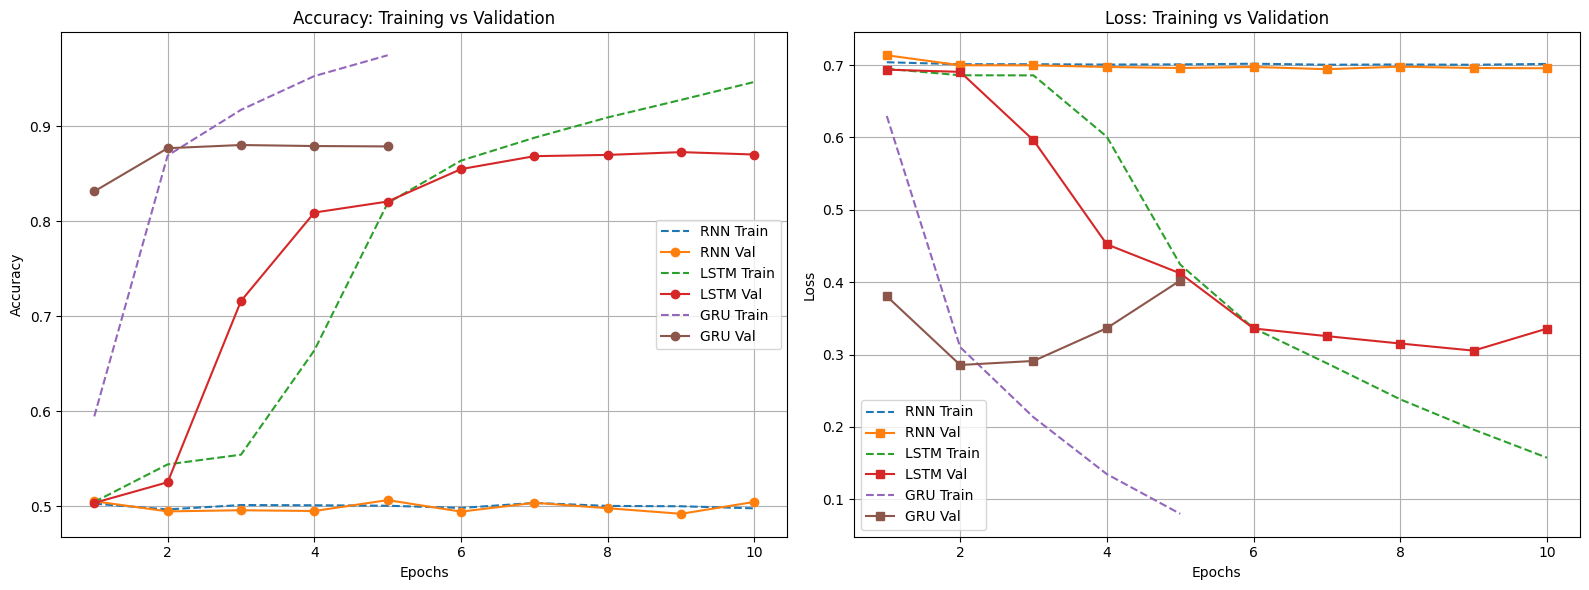

In [37]:
import matplotlib.pyplot as plt

def plot_training_results(results):
    # Create a figure with two subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    # --- 1. Accuracy Plot ---
    for model_name, history in results.items():
        # Calculate epochs for THIS specific model
        model_epochs = range(1, len(history['train_loss']) + 1)

        ax1.plot(model_epochs, history['train_acc'], label=f'{model_name} Train', linestyle='--')
        ax1.plot(model_epochs, history['val_acc'], label=f'{model_name} Val', marker='o')

    ax1.set_title('Accuracy: Training vs Validation')
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Accuracy')
    ax1.legend()
    ax1.grid(True)

    # --- 2. Loss Plot ---
    for model_name, history in results.items():
        # Calculate epochs for THIS specific model
        model_epochs = range(1, len(history['train_loss']) + 1)

        ax2.plot(model_epochs, history['train_loss'], label=f'{model_name} Train', linestyle='--')
        ax2.plot(model_epochs, history['val_loss'], label=f'{model_name} Val', marker='s')

    ax2.set_title('Loss: Training vs Validation')
    ax2.set_xlabel('Epochs')
    ax2.set_ylabel('Loss')
    ax2.legend()
    ax2.grid(True)

    plt.tight_layout()
    plt.show()

plot_training_results(results)

In [38]:
test_loader = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=32)

In [39]:
def run_final_benchmark(m_types, test_loader, device):
    final_scores = {}

    for m_type in m_types:
        model = SentimentModel(vocab_size, 128, 256, model_type=m_type, drop_prob=0.5).to(device)

        try:
            model.load_state_dict(torch.load(f'best_{m_type}_model.pt'))
            model.eval()

            correct = 0
            with torch.no_grad():
                for inputs, labels in test_loader:
                    inputs, labels = inputs.to(device), labels.to(device)
                    outputs = model(inputs).squeeze()
                    preds = (outputs > 0.5).float()
                    correct += (preds == labels).sum().item()

            acc = correct / len(test_loader.dataset)
            final_scores[m_type] = acc
            print(f"{m_type} Test Accuracy: {acc:.2%}")
        except FileNotFoundError:
            print(f"Skipping {m_type}: No saved model found.")

    return final_scores

final_results = run_final_benchmark(['RNN', 'LSTM', 'GRU'], test_loader, device)

RNN Test Accuracy: 50.52%
LSTM Test Accuracy: 86.96%
GRU Test Accuracy: 87.84%


### 📊 Final Architecture Comparison

| Model | Test Accuracy | Performance Analysis |
| :--- | :---: | :--- |
| 🐢 **RNN** | `50.52%` | **Failed to learn.** The "Vanishing Gradient" problem meant it couldn't link words at the start of a review to the label at the end. |
| 🧠 **LSTM** | `86.96%` | **Excellent.** The "Cell State" acted as a memory highway, preserving context over the 200-word sequence. |
| 🏆 **GRU** | `87.84%` | **Winner.** Achieved the best score with fewer parameters. Its "Update Gate" was highly efficient at filtering which words carried sentiment. |

In [41]:
def predict_custom_review(review_text, model, w2id, max_length=200):
    model.eval()

    tokens = clean_text(review_text)

    encoded = [w2id.get(w, 1) for w in tokens]

    if len(encoded) < max_length:
        encoded += [0] * (max_length - len(encoded))
    else:
        encoded = encoded[:max_length]

    tensor = torch.tensor([encoded]).to(device)

    with torch.no_grad():
        probability = model(tensor).item()

    sentiment = "POSITIVE" if probability > 0.5 else "NEGATIVE"
    confidence = probability if sentiment == "POSITIVE" else 1 - probability

    print(f"Review: \"{review_text}\"")
    print(f"Sentiment: {sentiment} ({confidence:.2%} confidence)\n")

best_model = SentimentModel(vocab_size, 128, 256, model_type='GRU', drop_prob=0.5).to(device)
best_model.load_state_dict(torch.load('best_GRU_model.pt'))

predict_custom_review("The plot was slow, but the acting was phenomenal and the ending made me cry.", best_model, w2id)
predict_custom_review("Save your money. This was the worst film I have seen in a decade.", best_model, w2id)

Review: "The plot was slow, but the acting was phenomenal and the ending made me cry."
Sentiment: POSITIVE (80.92% confidence)

Review: "Save your money. This was the worst film I have seen in a decade."
Sentiment: NEGATIVE (99.60% confidence)

